# Time-Based Shopping Behavior Analysis

This notebook analyzes when users typically place their orders during the day.  
The goal is to classify users as **Morning Buyers**, **Afternoon Buyers**, or **Night Shoppers** based on their average order hour,  
and then explore how this time-based behavior relates to other features such as purchase frequency and basket size.


Load the necessary data

We start by loading the `orders.csv` file from the Instacart dataset,  
which contains the order time (`order_hour_of_day`) for each user.

In [1]:
import pandas as pd
import numpy as np

# Load orders dataset
orders = pd.read_csv("../data/orders.csv")

# Keep only 'prior' orders
orders_prior = orders[orders["eval_set"] == "prior"]

print("Orders loaded:", orders_prior.shape)
orders_prior.head()


Orders loaded: (3214874, 7)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


Compute average order hour per user

We calculate the mean purchase hour for each user to understand when they usually shop.


In [4]:
# === 2.1 Keep only users with >= 3 orders ===
order_counts = orders_prior.groupby("user_id")["order_number"].nunique().reset_index()
order_counts.columns = ["user_id", "num_orders"]

valid_users = order_counts[order_counts["num_orders"] >= 3]["user_id"]
orders_prior = orders_prior[orders_prior["user_id"].isin(valid_users)]

print("Users kept (>=3 orders):", orders_prior['user_id'].nunique())

# === 3. Compute mean purchase hour per user ===
user_hours = (
    orders_prior.groupby("user_id")["order_hour_of_day"]
    .mean()
    .reset_index()
    .rename(columns={"order_hour_of_day": "mean_order_hour_of_day"})
)


Users kept (>=3 orders): 206209


Categorize users into Morning, Afternoon, or Night shoppers

Users are classified based on their average purchase hour:
- **Morning Buyer:** 7–11  
- **Afternoon Buyer:** 12–17  
- **Night Shopper:** 18–23  
- **Late Night / Early Morning:** 0–6


In [5]:
def categorize_hour(hour):
    if 7 <= hour < 12:
        return "Morning Buyer"
    elif 12 <= hour < 18:
        return "Afternoon Buyer"
    elif 18 <= hour <= 23:
        return "Night Shopper"
    else:
        return "Late Night / Early Morning"

user_hours["time_category"] = user_hours["mean_order_hour_of_day"].apply(categorize_hour)
user_hours.head()

,user_id,mean_order_hour_of_day,time_category
0,1,10.300000,Morning Buyer
1,2,10.571429,Morning Buyer
2,3,16.416667,Afternoon Buyer
3,4,12.600000,Afternoon Buyer
4,5,16.000000,Afternoon Buyer


Summary statistics of time-based categories

We calculate the proportion of users in each time category and basic descriptive statistics (mean and standard deviation of purchase hour).


In [6]:
# Percentage of users per category
summary = user_hours["time_category"].value_counts(normalize=True) * 100
print("User distribution by time category (%):\n")
print(summary.round(2))

# Basic descriptive stats
group_stats = (
    user_hours.groupby("time_category")["mean_order_hour_of_day"]
    .agg(["count", "mean", "std"])
    .round(2)
)
print("\nAverage order hour per category:")
print(group_stats)

User distribution by time category (%):

time_category
Afternoon Buyer               76.78
Morning Buyer                 20.71
Night Shopper                  2.30
Late Night / Early Morning     0.21
Name: proportion, dtype: float64

Average order hour per category:
                             count   mean   std
time_category                                  
Afternoon Buyer             158330  14.21  1.41
Late Night / Early Morning     432   5.60  1.22
Morning Buyer                42712  10.77  0.98
Night Shopper                 4735  18.84  0.84


Visualize user distribution by time category

We plot the share of users per time category to visualize which time periods dominate the shopping activity.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

Distribution of all purchase hours

We plot the overall distribution of `order_hour_of_day` for all prior orders.  
This visualization helps identify when shopping activity peaks during the day.

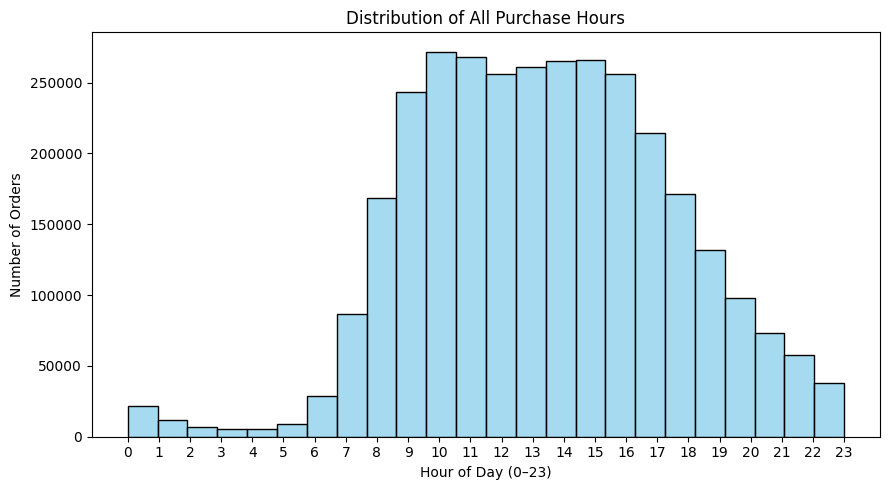

In [10]:
plt.figure(figsize=(9,5))
sns.histplot(orders_prior["order_hour_of_day"], bins=24, kde=False, color="skyblue")
plt.title("Distribution of All Purchase Hours")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Orders")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

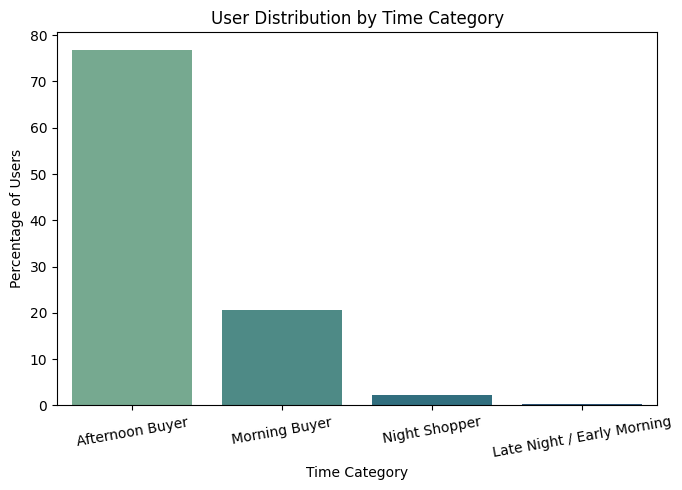

In [11]:
plt.figure(figsize=(7,5))
sns.barplot(
    x=summary.index,
    y=summary.values,
    hue=summary.index,     # προσθέτουμε hue για να δουλέψει σωστά το palette
    palette="crest",
    legend=False
)
plt.title("User Distribution by Time Category")
plt.xlabel("Time Category")
plt.ylabel("Percentage of Users")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


Merge time categories with other user-level features (optional)

If we already have user-level metrics (e.g., frequency, basket size) from previous analysis,  
we can merge them to compare behaviors between time categories.

In [9]:
# Load previously computed user-level metrics if available
try:
    periodicity = pd.read_csv("../data/user_periodicity.csv")
    user_features = pd.merge(periodicity, user_hours, on="user_id", how="inner")
    print("Merged shape:", user_features.shape)
except FileNotFoundError:
    print("File user_periodicity.csv not found. Skipping merge step.")


Merged shape: (206209, 8)


Interpretation

The results show that:
- Most users are **Afternoon Buyers**, typically placing orders around 2 p.m.  
- Around one-fifth are **Morning Buyers**, shopping around 10–11 a.m.  
- Only a very small share are **Night Shoppers**.

This indicates that shopping time is a **stable behavioral pattern** among users.  
It can be used as an additional feature for clustering,  
but it does not show enough diversity to support a standalone time-based recommendation model.

Relationship Between Purchase Time and Periodicity

We combine the time-based user categories (Morning, Afternoon, Night)  
with their periodicity categories (Stable, Moderate, Irregular)  
to analyze whether users who shop at different times of day also differ in purchase regularity.


In [12]:
# Load both datasets
periodicity = pd.read_csv("../data/user_periodicity.csv")
user_hours = user_hours[["user_id", "time_category"]]  # from previous cells

# Merge on user_id
merged_behavior = pd.merge(periodicity, user_hours, on="user_id", how="inner")

print("Merged shape:", merged_behavior.shape)
merged_behavior.head()


Merged shape: (206209, 7)


,user_id,mean,std,count,cv,periodicity_category,time_category
0,1,20.259259,9.304463,54,0.459270,Stable Periodicity,Morning Buyer
1,2,15.967033,9.119769,182,0.571162,Moderate Periodicity,Morning Buyer
2,3,11.487179,4.869048,78,0.423868,Stable Periodicity,Afternoon Buyer
3,4,15.357143,8.580901,14,0.558756,Moderate Periodicity,Afternoon Buyer
4,5,14.500000,4.263801,26,0.294055,Stable Periodicity,Afternoon Buyer


In [13]:
relation = (
    merged_behavior.groupby("time_category")["periodicity_category"]
    .value_counts(normalize=True)
    .unstack()
    .round(3) * 100
)

print("Percentage distribution of periodicity per time category:\n")
print(relation)


Percentage distribution of periodicity per time category:

periodicity_category        Irregular  Moderate Periodicity  \
time_category                                                 
Afternoon Buyer                   2.9                  50.1   
Late Night / Early Morning        4.9                  30.1   
Morning Buyer                     3.3                  44.9   
Night Shopper                     2.7                  29.5   

periodicity_category        Stable Periodicity  
time_category                                   
Afternoon Buyer                           46.9  
Late Night / Early Morning                65.0  
Morning Buyer                             51.8  
Night Shopper                             67.8  


<Figure size 800x500 with 0 Axes>

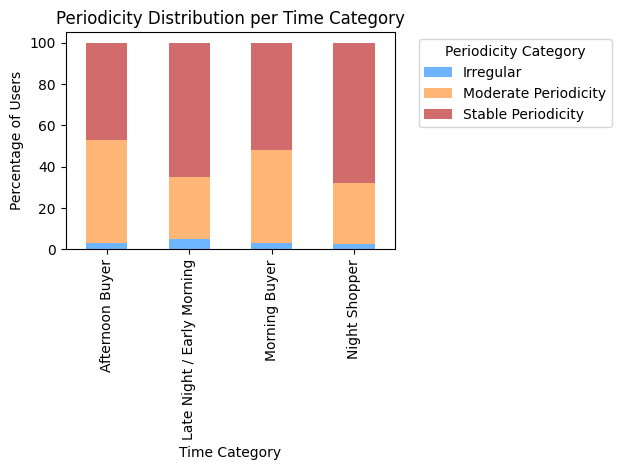

In [14]:
plt.figure(figsize=(8,5))
relation.plot(kind="bar", stacked=True, color=["#6DB6FF", "#FFB677", "#D26C6C"])
plt.title("Periodicity Distribution per Time Category")
plt.xlabel("Time Category")
plt.ylabel("Percentage of Users")
plt.legend(title="Periodicity Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
